In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import image_grid
from wildlife_tools.data import FeatureDataset

In [88]:
root_dir = "/media/filming/2025-白海豚/20240825-JM_02-1/"
features = FeatureDataset.from_file(root_dir+"/deepfeatures")
print("Total FinID count:", len(features.metadata.FinID.unique()))
updated_fin_id_list = features.metadata.FinID.values

Total FinID count: 161


In [89]:
def stats_fin_id(_fin_id_list):
    max_id = int(np.max(_fin_id_list))
    fin_counter = np.zeros(max_id+1, dtype=np.int16)
    # fin_id count from 1, 0 maens unclassfied fins
    for i in range(len(_fin_id_list)):
        fin_id = int(_fin_id_list[i])
        fin_counter[fin_id ]  = fin_counter[fin_id] + 1
    return fin_counter

def print_fin_distribution(_fin_id_list):
    fin_stats = stats_fin_id(_fin_id_list)
    stats_text = "unclassified fin: %d\n"%(fin_stats[0])
    for i in range(1, len(fin_stats)):
        stats_text = stats_text + "fin %d: %d\n"%(i, fin_stats[i])
    print(stats_text)

def imshow_fin_image_from_label(label):
    indices = np.where(fin_id_list==label)[0]
    file_list = []
    annotation_list = []
    for index in indices:
        file_list.append(features.metadata.loc[index, 'path'])
        annotation_list.append(features.metadata.loc[index, 'identity'] 
                                       + ' ' + "%d"%index
                                       + ' ' + features.metadata.loc[index, 'path'][-15:])
    image_grid.image_grid(file_list, top=100, text=annotation_list)

In [90]:
# Pick the fin with clearest image for each FinID
uniqued_fin_id = features.metadata.FinID[features.metadata.FinID!=0].unique() 
preview_fin_list = []
preview_fin_path_list = []
preview_fin_annotation_list = []
for fin in uniqued_fin_id:
    fin_group = features.metadata.query("FinID==%d"%fin)
    preview_fin_list.append(fin_group['clearness'].idxmax() )
    preview_fin_path_list.append( root_dir + "/" + fin_group.loc[fin_group['clearness'].idxmax(), 'path'] )     
    preview_fin_annotation_list.append("FinID%d count: %s"%(fin, len(fin_group)))

In [32]:
import multiprocessing.connection

In [92]:
checkbox_server = multiprocessing.connection.Listener(
    ('localhost', 1126), authkey=b'dolphin')

In [93]:
receiver = checkbox_server.accept()

In [91]:
checkbox_server.close()

In [94]:
# merge fin
# TODO: sort fin based on similarity comparing with the the first
# TODO: 排除同一原始图里出现同一个背鳍
def merge_fin():
    while True:
        # Send updated preview fin to GUI
        receiver.send({"idx": preview_fin_list, 
                       "path": preview_fin_path_list,
                      "annotation": preview_fin_annotation_list})
        # Receive from GUI
        user_merged_fin_idx_list = receiver.recv()
        print(user_merged_fin_idx_list)
        if len(user_merged_fin_idx_list) > 1:
            # find clearest
            kept_fin_idx_list = user_merged_fin_idx_list
            kept_fin_clearness_list = features.metadata['clearness'][kept_fin_idx_list]
            kept_fin_idx = kept_fin_clearness_list.idxmax()
            kept_fin_id = updated_fin_id_list[kept_fin_idx]
            # remove other fins from preview, kept only kept_fin
            merged_fin_id_list = updated_fin_list[user_merged_fin_idx_list]
            removed_fin_idx_list = []
            for fin_idx in user_merged_fin_idx_list:
                if fin_idx != kept_fin_idx :
                    del_preview_idx = preview_fin_list.index(fin_idx)
                    del preview_fin_list[del_preview_idx]
                    del preview_fin_path_list[del_preview_idx]
                    del preview_fin_annotation_list[del_preview_idx]
            # replace other fin id with kept_fin_id
            for old_id in merged_fin_id_list:
                if old_id!=kept_fin_id:
                    updated_fin_list[updated_fin_list == old_id] = kept_fin_id

In [95]:
merge_fin()

[np.int64(2355), np.int64(1)]
[np.int64(67), np.int64(23), np.int64(3447)]
[np.int64(2005), np.int64(730), np.int64(820)]
[np.int64(927), np.int64(2458)]
[np.int64(2458), np.int64(158)]
[np.int64(252), np.int64(2355)]
[np.int64(221), np.int64(2503)]
[np.int64(319), np.int64(7)]
[np.int64(2503), np.int64(319)]
[np.int64(2562), np.int64(375)]
[np.int64(465), np.int64(456)]
[np.int64(855), np.int64(906), np.int64(862)]
[np.int64(2303), np.int64(228)]
[np.int64(2503), np.int64(472)]
[np.int64(750), np.int64(806)]
[np.int64(923), np.int64(900)]
[np.int64(1186), np.int64(1167)]
[np.int64(1000), np.int64(3194)]
[np.int64(820), np.int64(1714), np.int64(2023)]
[np.int64(3491), np.int64(3547)]
[np.int64(376), np.int64(2303)]
[np.int64(3434), np.int64(371), np.int64(2393), np.int64(3012), np.int64(2811), np.int64(3194), np.int64(2649)]
[np.int64(2355), np.int64(2502)]
[np.int64(3617), np.int64(3654)]
[np.int64(3619), np.int64(3617)]
[np.int64(915), np.int64(917)]
[np.int64(3596), np.int64(2537), 

EOFError: 

In [98]:
# relabel fin id
existed_fin_id = []
for i in updated_fin_list:
    if (i not in existed_fin_id) and (i != 0):
        existed_fin_id.append(i)
sorted_existed_fin_id = np.sort(existed_fin_id)
for i in range(len(sorted_existed_fin_id)):
    updated_fin_list[updated_fin_list == sorted_existed_fin_id[i]] = i + 1
features.metadata.FinID= updated_fin_list
plt.plot(stats_fin_id(updated_fin_list), '*')
plt.savefig("FinID_statistics.png")
plt.show()
print_fin_distribution(updated_fin_list)

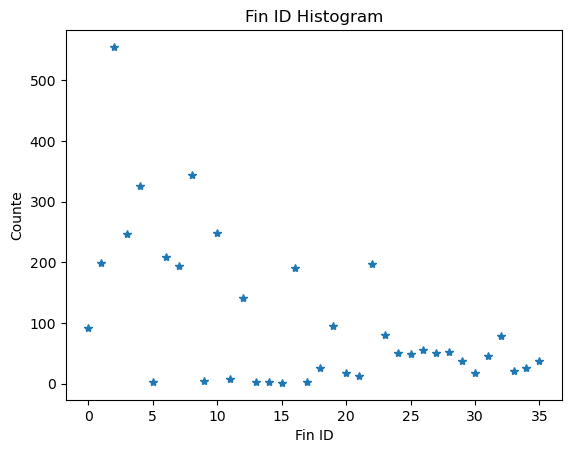

In [114]:
plt.plot(features.metadata['FinID'].value_counts(), "*")
plt.title("Fin ID Histogram")
plt.xlabel("Fin ID")
plt.ylabel("Counte")
plt.savefig(root_dir + "/FinID_statistics.png")
plt.show()
#print_fin_distribution(updated_fin_list)

In [102]:
features.save(root_dir + "/deepfeatures_MERGED")
features.metadata.to_csv(root_dir + "/FIN_METAINFO_SELECTED_MERGED.csv")

In [115]:
import os
import shutil
from pathlib import Path

In [116]:
def creat_empty_folder(folder):
    folder_path = Path(folder)
    if folder_path.exists():
        shutil.rmtree(folder_path)
        print(f"Deleted: {folder_path}")
    os.mkdir(folder)

In [176]:
max_FinID = features.metadata["FinID"].max()

for i in range(max_FinID+1):
    paths = features.metadata.query("FinID==%d"%i)['path']
    if i == 0 :
        dest_dir = root_dir + "/FIN/Fin_NoLabel"
    else:
        dest_dir = root_dir + "/FIN/FinID%03d/"%i
    creat_empty_folder(dest_dir)
    for fin in paths:
        fin_file = os.path.basename(fin)
        src = os.path.join(root_dir,  fin)
        dest = os.path.join(dest_dir, fin_file)
        os.symlink(src, dest)

Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/Fin_NoLabel
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID001
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID002
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID003
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID004
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID005
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID006
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID007
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID008
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID009
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID010
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID011
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID012
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID013
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/FinID014
Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FI

In [170]:
        dest_dir = root_dir + "/FIN/Fin_NoLabel"

In [171]:
    creat_empty_folder(dest_dir)


Deleted: /media/filming/2025-白海豚/20240825-JM_02-1/FIN/Fin_NoLabel


In [ ]:
os.path.join

In [172]:
    for fin in paths:
        src = root_dir + "/" + fin
        dest = dest_dir + fin[4:]
        os.symlink(src, dest)

FileExistsError: [Errno 17] File exists: '/media/filming/2025-白海豚/20240825-JM_02-1//FIN/0021_20240825JM02ZRA10895_FIN01.JPG' -> '/media/filming/2025-白海豚/20240825-JM_02-1//FIN/Fin_NoLabel0021_20240825JM02ZRA10895_FIN01.JPG'

In [173]:
dest

'/media/filming/2025-白海豚/20240825-JM_02-1//FIN/Fin_NoLabel0021_20240825JM02ZRA10895_FIN01.JPG'

In [175]:
paths

2       FIN/0021_20240825JM02ZRA10895_FIN01.JPG
19      FIN/0087_20240825JM02ZRA10961_FIN01.JPG
35      FIN/0097_20240825JM02ZRA10971_FIN00.JPG
36      FIN/0103_20240825JM02ZRA10977_FIN00.JPG
37      FIN/0104_20240825JM02ZRA10978_FIN00.JPG
                         ...                   
3615    FIN/3368_20240825JM02ZRA14244_FIN00.JPG
3663    FIN/3434_20240825JM02ZRA14310_FIN01.JPG
3664    FIN/3435_20240825JM02ZRA14311_FIN00.JPG
3669    FIN/3437_20240825JM02ZRA14313_FIN01.JPG
3703    FIN/3466_20240825JM02ZRA14342_FIN00.JPG
Name: path, Length: 92, dtype: object